In [1]:
#decision tree regressor


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df=load_diabetes(as_frame=True).frame



In [3]:
x = df.drop("target",axis=1)
y = df["target"]

In [4]:
x.head()
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [5]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.3,random_state=42
)


In [6]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=20
)

model.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [7]:
from sklearn.metrics import r2_score,mean_squared_error

y_pred_train =  model.predict(x_train)
y_pred_test = model.predict(x_test)

print("MSE train: ",mean_squared_error(y_train,y_pred_train))
print("MSE test: ",mean_squared_error(y_test,y_pred_test))

print("r^2 train: ",r2_score(y_train,y_pred_train))
print("r^2 test: ",r2_score(y_test,y_pred_test))

      

MSE train:  1784.9583905602838
MSE test:  4044.643175692023
r^2 train:  0.7096817553064192
r^2 test:  0.2507572087221992


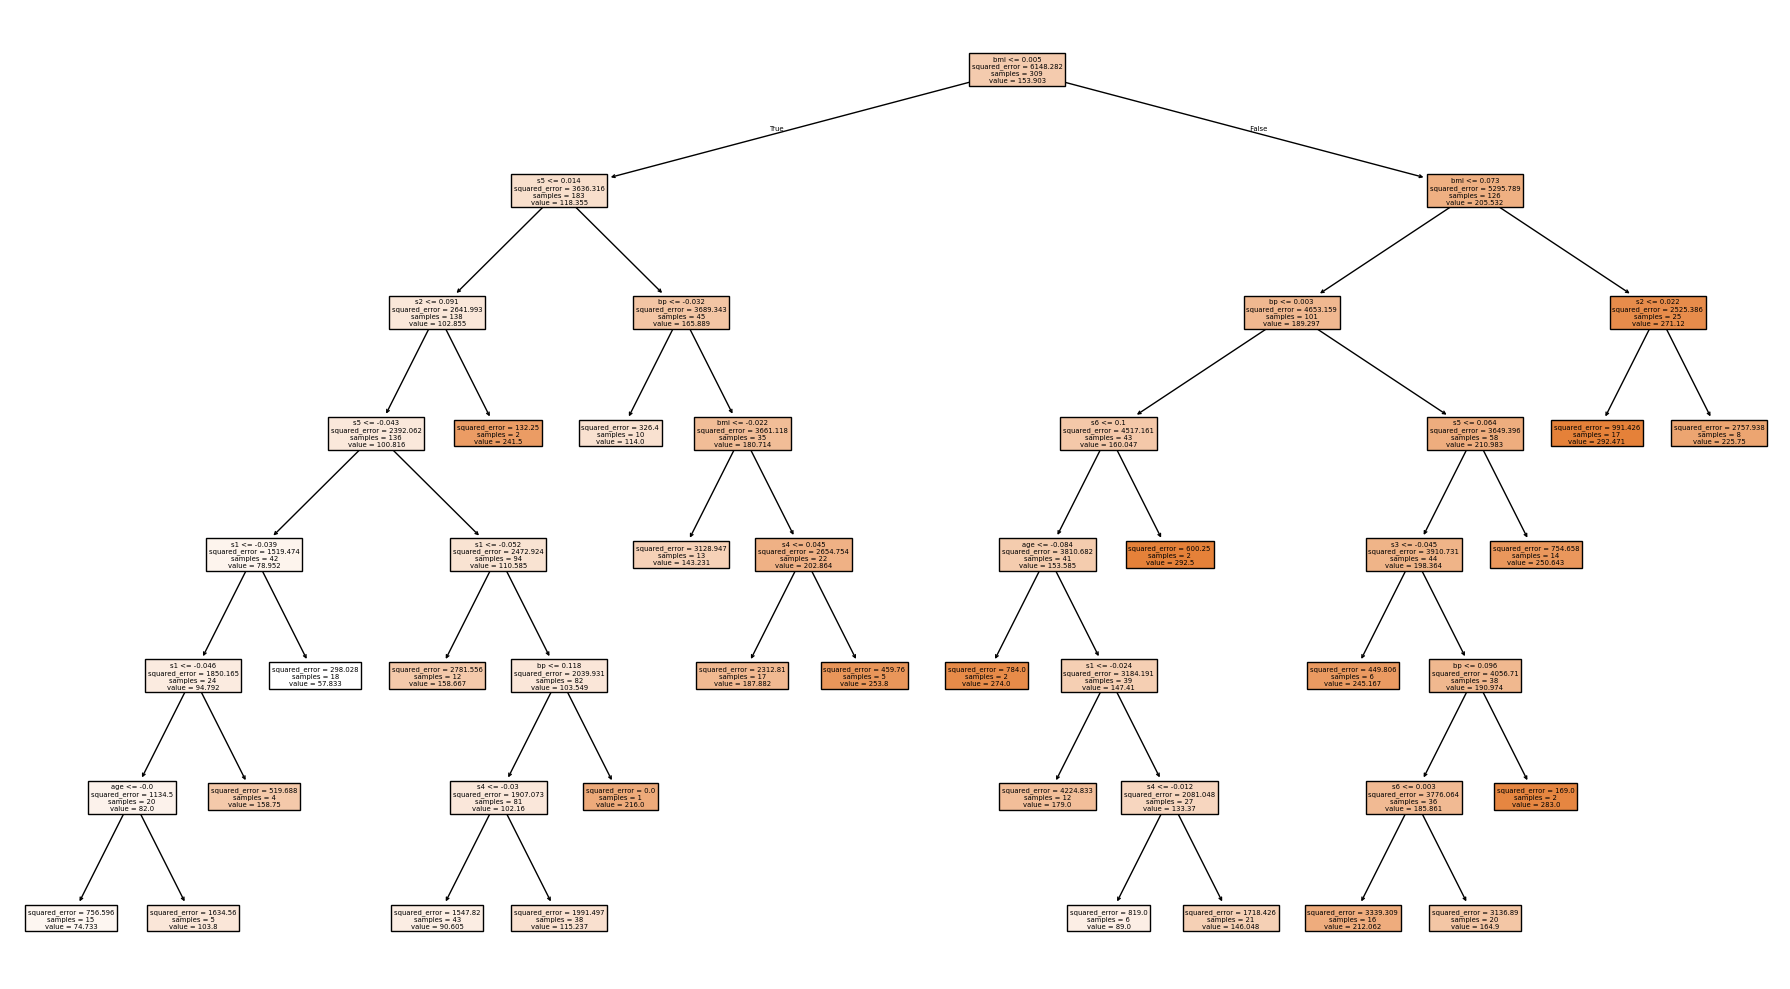

In [8]:
from sklearn.tree import  plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True
)
plt.tight_layout()

Decision Tree with pre-pruning 


In [9]:
from sklearn.tree import DecisionTreeClassifier

max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"For depth={depth}, accuracy={acc}")

For depth=2, accuracy=0.007518796992481203
For depth=3, accuracy=0.007518796992481203
For depth=4, accuracy=0.007518796992481203
For depth=5, accuracy=0.0
For depth=6, accuracy=0.0
For depth=7, accuracy=0.0
For depth=8, accuracy=0.007518796992481203
For depth=9, accuracy=0.007518796992481203
For depth=10, accuracy=0.007518796992481203


c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classe

In [10]:
print(x.shape)
print(y.shape)

print(y.value_counts())

(442, 10)
(442,)
target
200.0    6
72.0     6
90.0     5
71.0     5
178.0    5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64


Post-Pruning in Decision Tree


In [11]:
full_tree= DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [12]:
path = full_tree.cost_complexity_pruning_path(x_train, y_train)

ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625 0.00323625
 0.00323625 0.00381877 0.0038835  0.00401834 0.00404531 0.00404531
 0.00404531 0.00404881 0.00409463 0.00418808 0.00420712 0.00420712
 0.00420712 0.00422869 0.00431499 0.00431499 0.00431499 0.00431499
 0.00431499 0.00431499 0.00431499 0.00431499 0.00444632 0.00446436
 0.00457499 0.00467458 0.004728   0.00476426 0.00481085 0.00481727
 0.00483886 0.00490587]


c:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


In [13]:
for alpha in ccp_alphas:

    model = DecisionTreeRegressor(
        ccp_alpha=alpha
    )

    model.fit(x_train, y_train)

    score = model.score(x_test, y_test)

    print(alpha, score)

0.0 -0.08556157729594216
0.0032362459546925564 -0.06150050047823519
0.0032362459546925564 -0.14964389817953516
0.0032362459546925564 -0.05238910994714385
0.0032362459546925564 -0.1057363763700212
0.0032362459546925564 -0.12395149699762276
0.0032362459546925564 -0.05555252122757204
0.0032362459546925564 -0.010474693935007107
0.0032362459546925564 -0.03073410599105042
0.0032362459546925564 -0.1479909853178738
0.0032362459546925564 -0.13512284802788987
0.0032362459546925564 -0.10389264904697582
0.0032362459546925564 -0.1449999338155208
0.0032362459546925564 -0.0028017240973059465
0.0032362459546925564 -0.0758345663857869
0.0032362459546925564 -0.012126213990381052
0.0032362459546925564 -0.03680395579186757
0.0032362459546925564 -0.02974974014737719
0.0032362459546925564 -0.07825456731027502
0.0032362459546925564 -0.048580829355614696
0.0032362459546925564 -0.043419437455803234
0.0032362459546925564 -0.00903696964476075
0.0032362459546925564 0.03173464880850241
0.0032362459546925564 -0.100